# Visualize deep-MPN performance on example trials

Reload trained `dmpn` networks (one seed, each learning rule), generate held-out
trials, run the networks, and inspect performance — mirroring
MultiTaskMPN/one_task's example-trial figure:

- **top panel:** the input channels of one trial (fixation, stimulus, task cue).
- **bottom panel:** per output channel, the **target** (faded, thick) vs. the
  **network output** (solid). A well-trained net's output tracks the target.

Plus a held-out **angle-accuracy** summary per rule. Set `SEED` / `RULES` below to
match a completed `train_mpn.py` run (checkpoints assumed `dmpn`).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import _bootstrap  # noqa: F401  -- prepends ../core + ../scripts to sys.path
import mpn_tasks
import train_mpn as tm
import train_common as tc   # try_accuracy lives here

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1. Choose the run to load

`tm.ckpt_path(rule, seed)` builds the checkpoint path from the current `train_mpn`
config, so if the saved run used non-default settings, override `tm.*` here BEFORE
loading (e.g. `tm.RULESET`, `tm.N_HIDDEN`, `tm.N_DATASETS`).

In [2]:
# --- run selection ---
SEED = tm.SEED                # e.g. 42; use tm.SEED + k for the k-th run
RULES = ["bptt", "local_diag_rflo", "local_direct"]
DEVICE = torch.device("cpu")

# If the saved run used non-default config, override tm.* here BEFORE loading:
# tm.RULESET = "delaygo"; tm.N_HIDDEN = 200; tm.N_DATASETS = 5000

nets = {}
for rule in RULES:
    path = tm.ckpt_path(rule, SEED)
    nets[rule] = tm.load_net(path, device=DEVICE)
    nets[rule].eval()
    print(f"{rule:20} <- {path}")

any_net = nets[RULES[0]]
print(f"\nn_input={any_net.n_input}  n_hidden={any_net.n_hidden}  n_output={any_net.n_output}")

bptt                 <- /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/checkpoints/dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_exact_readout_bptt_seed42.pt
local_diag_rflo      <- /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/checkpoints/dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_exact_readout_local_diag_rflo_seed42.pt
local_direct         <- /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/checkpoints/dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_exact_readout_local_direct_seed42.pt

n_input=6  n_hidden=200  n_output=3


## 2. Generate held-out trials and run each network

We draw a fresh batch of the task the checkpoints were trained on (`tm.RULESET`),
then run every rule's network on the SAME trials so their outputs are directly
comparable. `tm.forward_outputs` is the no-grad unrolled forward used in training.

In [3]:
# Build the task params exactly as train_mpn does, then draw a held-out batch.
task_params, train_params, net_params = tm.build_params()
task_params, train_params, net_params = mpn_tasks.convert_and_init_multitask_params(
    (task_params, train_params, net_params))
net_params["prefs"] = mpn_tasks.get_prefs(task_params["hp"])

N_TRIALS = 8
np.random.seed(SEED); torch.manual_seed(SEED)
data, _ = mpn_tasks.generate_trials_wrap(
    task_params, N_TRIALS, rules=task_params["rules"],
    mode_input="random_batch", device=DEVICE)
inputs, labels, mask = (d.to(next(any_net.parameters()).dtype) for d in data)
inputs_np = inputs.cpu().numpy()
labels_np = labels.cpu().numpy()          # target output (B, T, n_output)

# Run every rule's net on the SAME trials.
outputs = {rule: tm.forward_outputs(net, inputs).cpu().numpy()
           for rule, net in nets.items()}
print(f"trials: inputs {inputs_np.shape}  target {labels_np.shape}")
print(f"task = {tm.RULESET}  |  n_input={inputs_np.shape[-1]}  n_output={labels_np.shape[-1]}")

trials: inputs (8, 121, 6)  target (8, 121, 3)
task = contextdelaydm1  |  n_input=6  n_output=3


## 3. Example-trial figure — input, target, and each rule's output

One column per example trial. Top row: input channels. Following rows: one per
learning rule, showing the **target** (faded thick line) vs. that rule's
**network output** (solid) for every output channel. Output tracking the target
= the network solves the trial.

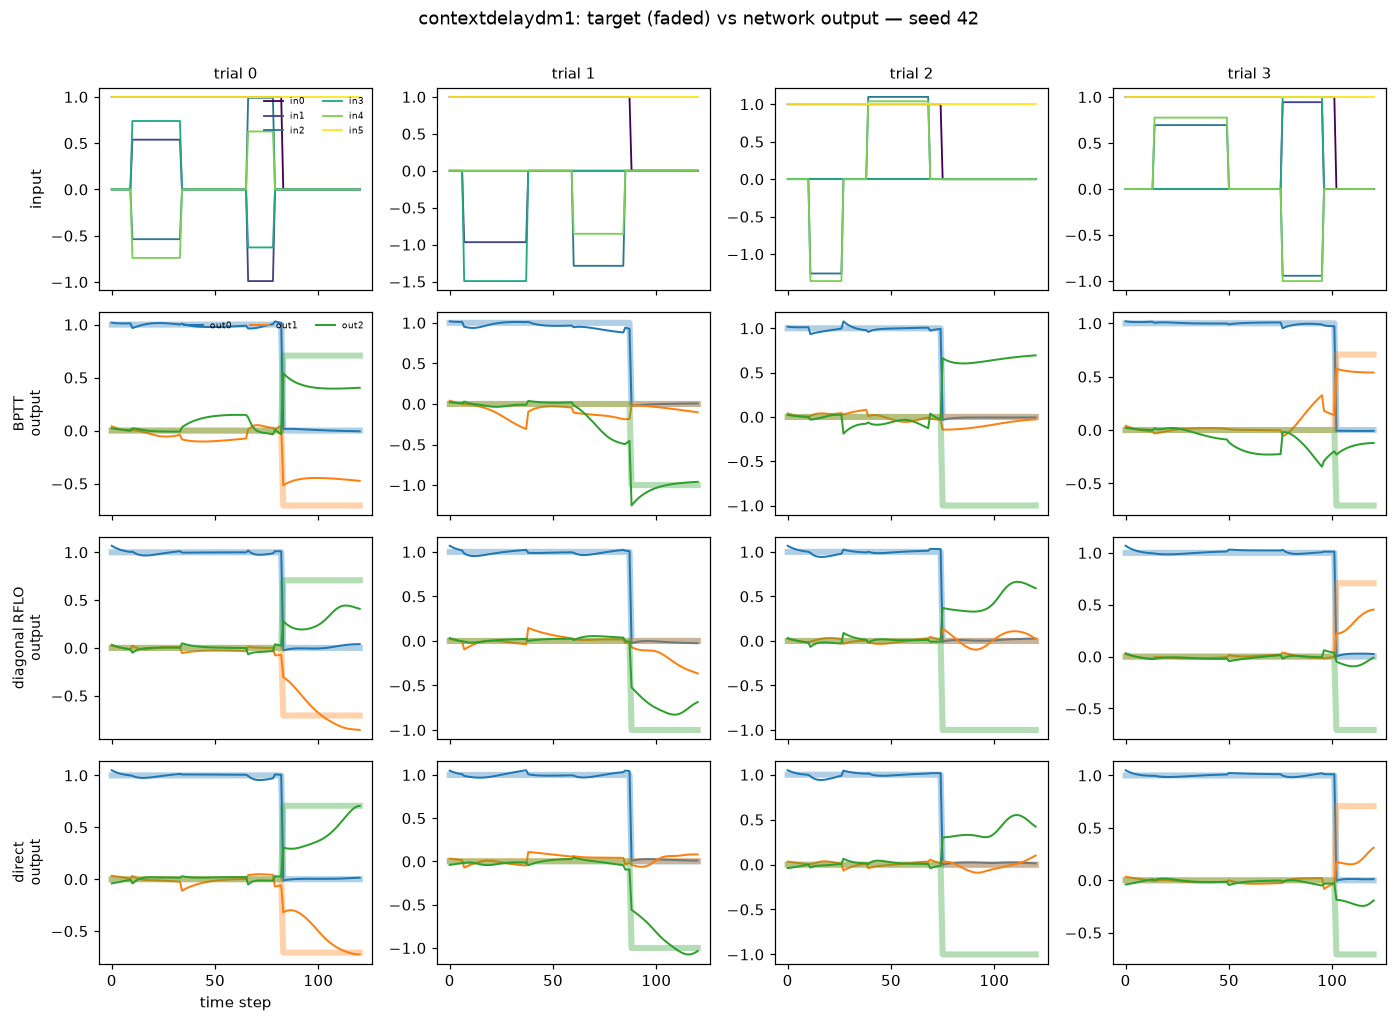

In [4]:
N_SHOW = min(4, N_TRIALS)              # example trials (columns) to display
n_out = labels_np.shape[-1]
n_in = inputs_np.shape[-1]

nrows = 1 + len(RULES)                 # input row + one row per rule
fig, axes = plt.subplots(nrows, N_SHOW, figsize=(3.2 * N_SHOW, 2.3 * nrows),
                         squeeze=False, sharex=True)
in_cmap = plt.cm.viridis(np.linspace(0, 1, n_in))
out_cmap = plt.cm.tab10(np.arange(n_out))

for c in range(N_SHOW):
    # Top: input channels for trial c.
    ax = axes[0][c]
    for ch in range(n_in):
        ax.plot(inputs_np[c, :, ch], color=in_cmap[ch], lw=1.2,
                label=f"in{ch}" if c == 0 else None)
    ax.set_title(f"trial {c}", fontsize=10)
    if c == 0:
        ax.set_ylabel("input", fontsize=10)
        ax.legend(fontsize=6, ncol=2, frameon=False, loc="upper right")

    # One row per rule: target (faded) vs network output (solid).
    for r, rule in enumerate(RULES):
        ax = axes[1 + r][c]
        for o in range(n_out):
            ax.plot(labels_np[c, :, o], color=out_cmap[o], lw=4, alpha=0.35)
            ax.plot(outputs[rule][c, :, o], color=out_cmap[o], lw=1.3,
                    label=f"out{o}" if c == 0 else None)
        if c == 0:
            ax.set_ylabel(f"{tm.RULE_LABEL.get(rule, rule)}\noutput", fontsize=9)
            if r == 0:
                ax.legend(fontsize=6, ncol=n_out, frameon=False, loc="upper right")
axes[-1][0].set_xlabel("time step", fontsize=10)
fig.suptitle(f"{tm.RULESET}: target (faded) vs network output — seed {SEED}",
             y=1.005, fontsize=12)
fig.tight_layout()
plt.show()

## 4. Held-out accuracy per rule

The library's angle accuracy on the held-out batch (train uses `isvalid=False`;
here we use `isvalid=True`, the task-aligned evaluation, matching how `valid_acc`
is measured during training).

In [5]:
print(f"{'rule':20} {'held-out angle acc':>18}")
for rule, net in nets.items():
    out = torch.tensor(outputs[rule], dtype=inputs.dtype)
    acc = tc.try_accuracy(net, out, labels, mask, inputs, isvalid=True)
    print(f"{tm.RULE_LABEL.get(rule, rule):20} {acc:>18.3f}")

rule                 held-out angle acc
BPTT                              0.450
diagonal RFLO                     0.680
direct                            0.570
